In [2]:
from pathlib import Path

import polars as pl
import pandas as pd
import numpy as np

In [3]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_FILE = PROJECT_ROOT / "data" / "splits" / "train" / "trips_train.parquet"
VALIDATION_FILE = PROJECT_ROOT / "data" / "splits" / "validation" / "trips_validation.parquet"
TEST_FILE = PROJECT_ROOT / "data" / "splits" / "test" / "trips_test.parquet"

print("Train exists:", TRAIN_FILE.exists())
print("Validation exists:", VALIDATION_FILE.exists())
print("Test exists:", TEST_FILE.exists())

Train exists: True
Validation exists: True
Test exists: True


In [4]:
train_df = pl.scan_parquet(TRAIN_FILE)
validation_df = pl.scan_parquet(VALIDATION_FILE)
test_df = pl.scan_parquet(TEST_FILE)

print("Train columns:", len(train_df.collect_schema()))
print("Validation columns:", len(validation_df.collect_schema()))
print("Test columns:", len(test_df.collect_schema()))

print("\nTrain schema:")
for name, dtype in train_df.collect_schema().items():
    print(f"{name}: {dtype}")

Train columns: 20
Validation columns: 20
Test columns: 20

Train schema:
provider_code: Int64
pickup_timestamp: Datetime(time_unit='us', time_zone=None)
dropoff_timestamp: Datetime(time_unit='us', time_zone=None)
rider_count: Int64
distance_miles: Float64
rate_class_id: Int64
offline_record_flag: String
origin_loc_id: Int64
dest_loc_id: Int64
fare_settlement_method: Int64
base_fare: Float64
surcharge_misc: Float64
transit_tax: Float64
driver_tip_payment: Float64
toll_total: Float64
service_improvement_fee: Float64
charge_total: Float64
zone_congestion_fee: Float64
Airport_fee: Float64
congestion_relief_fee: Float64


In [5]:
fare_target_check = (
    train_df
    .select(
        [
            pl.len().alias("rows"),
            pl.col("base_fare").null_count().alias("null_base_fare"),
            pl.col("base_fare").min().alias("min_fare"),
            pl.col("base_fare").quantile(0.25).alias("q25"),
            pl.col("base_fare").median().alias("median"),
            pl.col("base_fare").quantile(0.75).alias("q75"),
            pl.col("base_fare").quantile(0.95).alias("q95"),
            pl.col("base_fare").quantile(0.99).alias("q99"),
            pl.col("base_fare").max().alias("max_fare"),
            pl.col("base_fare").mean().alias("mean_fare"),
        ]
    )
    .collect()
)

print(fare_target_check)

shape: (1, 10)
┌──────────┬────────────────┬──────────┬──────┬───┬──────┬──────┬───────────┬───────────┐
│ rows     ┆ null_base_fare ┆ min_fare ┆ q25  ┆ … ┆ q95  ┆ q99  ┆ max_fare  ┆ mean_fare │
│ ---      ┆ ---            ┆ ---      ┆ ---  ┆   ┆ ---  ┆ ---  ┆ ---       ┆ ---       │
│ u32      ┆ u32            ┆ f64      ┆ f64  ┆   ┆ f64  ┆ f64  ┆ f64       ┆ f64       │
╞══════════╪════════════════╪══════════╪══════╪═══╪══════╪══════╪═══════════╪═══════════╡
│ 33792312 ┆ 0              ┆ 0.0      ┆ 10.0 ┆ … ┆ 61.1 ┆ 79.3 ┆ 325478.05 ┆ 20.529724 │
└──────────┴────────────────┴──────────┴──────┴───┴──────┴──────┴───────────┴───────────┘


In [6]:
fare_extreme_check = (
    train_df
    .select(
        [
            (pl.col("base_fare") == 0)
            .sum()
            .alias("fare_equal_0"),

            (pl.col("base_fare") > 100)
            .sum()
            .alias("fare_over_100"),

            (pl.col("base_fare") > 200)
            .sum()
            .alias("fare_over_200"),

            (pl.col("base_fare") > 500)
            .sum()
            .alias("fare_over_500"),

            (pl.col("base_fare") > 1000)
            .sum()
            .alias("fare_over_1000"),

            (pl.col("base_fare") > 5000)
            .sum()
            .alias("fare_over_5000"),

            (pl.col("base_fare") > 10000)
            .sum()
            .alias("fare_over_10000"),
        ]
    )
    .collect()
)

print(fare_extreme_check)

shape: (1, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ fare_equal_0 ┆ fare_over_1 ┆ fare_over_2 ┆ fare_over_5 ┆ fare_over_1 ┆ fare_over_5 ┆ fare_over_1 │
│ ---          ┆ 00          ┆ 00          ┆ 00          ┆ 000         ┆ 000         ┆ 0000        │
│ u32          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│              ┆ u32         ┆ u32         ┆ u32         ┆ u32         ┆ u32         ┆ u32         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 16429        ┆ 112775      ┆ 12812       ┆ 405         ┆ 32          ┆ 2           ┆ 2           │
└──────────────┴─────────────┴─────────────┴─────────────┴─────────────┴─────────────┴─────────────┘


In [7]:
extreme_fares = (
    train_df
    .filter(
        pl.col("base_fare") > 5000
    )
    .select(
        [
            "pickup_timestamp",
            "dropoff_timestamp",
            "distance_miles",
            "rider_count",
            "origin_loc_id",
            "dest_loc_id",
            "rate_class_id",
            "fare_settlement_method",
            "base_fare",
            "charge_total",
        ]
    )
    .collect()
)

print(extreme_fares)

shape: (2, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ pickup_ti ┆ dropoff_t ┆ distance_ ┆ rider_cou ┆ … ┆ rate_clas ┆ fare_sett ┆ base_fare ┆ charge_t │
│ mestamp   ┆ imestamp  ┆ miles     ┆ nt        ┆   ┆ s_id      ┆ lement_me ┆ ---       ┆ otal     │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ thod      ┆ f64       ┆ ---      │
│ datetime[ ┆ datetime[ ┆ f64       ┆ i64       ┆   ┆ i64       ┆ ---       ┆           ┆ f64      │
│ μs]       ┆ μs]       ┆           ┆           ┆   ┆           ┆ i64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2025-06-1 ┆ 2025-06-1 ┆ 20.6      ┆ 3         ┆ … ┆ 2         ┆ 2         ┆ 325478.05 ┆ 325528.4 │
│ 1         ┆ 1         ┆           ┆           ┆   ┆           ┆           ┆           ┆ 5        │
│ 14:41:03  ┆ 16:14:37  ┆           ┆           ┆   ┆           ┆           

In [8]:
fare_outlier_split_check = pl.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "rows": [
            train_df.select(pl.len()).collect().item(),
            validation_df.select(pl.len()).collect().item(),
            test_df.select(pl.len()).collect().item(),
        ],
        "fare_over_5000": [
            train_df.select((pl.col("base_fare") > 5000).sum()).collect().item(),
            validation_df.select((pl.col("base_fare") > 5000).sum()).collect().item(),
            test_df.select((pl.col("base_fare") > 5000).sum()).collect().item(),
        ],
    }
)

fare_outlier_split_check = fare_outlier_split_check.with_columns(
    (
        pl.col("fare_over_5000")
        / pl.col("rows")
        * 100
    ).alias("percentage")
)

print(fare_outlier_split_check)

shape: (3, 4)
┌────────────┬──────────┬────────────────┬────────────┐
│ split      ┆ rows     ┆ fare_over_5000 ┆ percentage │
│ ---        ┆ ---      ┆ ---            ┆ ---        │
│ str        ┆ i64      ┆ i64            ┆ f64        │
╞════════════╪══════════╪════════════════╪════════════╡
│ Train      ┆ 33792312 ┆ 2              ┆ 0.000006   │
│ Validation ┆ 6730119  ┆ 0              ┆ 0.0        │
│ Test       ┆ 3764245  ┆ 0              ┆ 0.0        │
└────────────┴──────────┴────────────────┴────────────┘


In [9]:
fare_train_df = train_df.filter(pl.col("base_fare") <= 5000)
fare_validation_df = validation_df
fare_test_df = test_df

print(
    "Fare train rows:",
    fare_train_df.select(pl.len()).collect().item()
)

print(
    "Fare validation rows:",
    fare_validation_df.select(pl.len()).collect().item()
)

print(
    "Fare test rows:",
    fare_test_df.select(pl.len()).collect().item()
)

Fare train rows: 33792310
Fare validation rows: 6730119
Fare test rows: 3764245


In [10]:
TARGET = "base_fare"

fare_source_features = [
    "provider_code",
    "pickup_timestamp",
    "rider_count",
    "rate_class_id",
    "origin_loc_id",
    "dest_loc_id",
]

print("Target:", TARGET)
print("Source features:")
for feature in fare_source_features:
    print("-", feature)

Target: base_fare
Source features:
- provider_code
- pickup_timestamp
- rider_count
- rate_class_id
- origin_loc_id
- dest_loc_id


In [11]:
# Checking Missing Values

In [12]:
missing_check = (
    fare_train_df
    .select([
        pl.len().alias("rows"),
        pl.col("provider_code").null_count().alias("provider_code_nulls"),
        pl.col("rider_count").null_count().alias("rider_count_nulls"),
        pl.col("rate_class_id").null_count().alias("rate_class_id_nulls"),
        pl.col("origin_loc_id").null_count().alias("origin_loc_id_nulls"),
        pl.col("dest_loc_id").null_count().alias("dest_loc_id_nulls"),
    ])
    .collect()
)

print(missing_check)

shape: (1, 6)
┌──────────┬─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┐
│ rows     ┆ provider_code_n ┆ rider_count_nul ┆ rate_class_id_n ┆ origin_loc_id_ ┆ dest_loc_id_nu │
│ ---      ┆ ulls            ┆ ls              ┆ ulls            ┆ nulls          ┆ lls            │
│ u32      ┆ ---             ┆ ---             ┆ ---             ┆ ---            ┆ ---            │
│          ┆ u32             ┆ u32             ┆ u32             ┆ u32            ┆ u32            │
╞══════════╪═════════════════╪═════════════════╪═════════════════╪════════════════╪════════════════╡
│ 33792310 ┆ 0               ┆ 7261615         ┆ 7078136         ┆ 0              ┆ 0              │
└──────────┴─────────────────┴─────────────────┴─────────────────┴────────────────┴────────────────┘


In [13]:
imputation_values = (
    fare_train_df
    .select([
        pl.col("rider_count").median().alias("rider_count_median"),
        pl.col("rate_class_id").mode().first().alias("rate_class_id_mode"),
    ])
    .collect()
)

print(imputation_values)

shape: (1, 2)
┌────────────────────┬────────────────────┐
│ rider_count_median ┆ rate_class_id_mode │
│ ---                ┆ ---                │
│ f64                ┆ i64                │
╞════════════════════╪════════════════════╡
│ 1.0                ┆ 1                  │
└────────────────────┴────────────────────┘


In [14]:
RIDER_COUNT_FILL = 1
RATE_CLASS_FILL = 1

fare_train_df = fare_train_df.with_columns([
    pl.col("rider_count").fill_null(RIDER_COUNT_FILL),
    pl.col("rate_class_id").fill_null(RATE_CLASS_FILL),
])

fare_validation_df = fare_validation_df.with_columns([
    pl.col("rider_count").fill_null(RIDER_COUNT_FILL),
    pl.col("rate_class_id").fill_null(RATE_CLASS_FILL),
])

fare_test_df = fare_test_df.with_columns([
    pl.col("rider_count").fill_null(RIDER_COUNT_FILL),
    pl.col("rate_class_id").fill_null(RATE_CLASS_FILL),
])

print("Imputation applied.")

Imputation applied.


In [15]:
verify_imputation = (
    fare_train_df
    .select([
        pl.col("rider_count").null_count().alias("rider_count_nulls"),
        pl.col("rate_class_id").null_count().alias("rate_class_id_nulls"),
    ])
    .collect()
)

print(verify_imputation)

shape: (1, 2)
┌───────────────────┬─────────────────────┐
│ rider_count_nulls ┆ rate_class_id_nulls │
│ ---               ┆ ---                 │
│ u32               ┆ u32                 │
╞═══════════════════╪═════════════════════╡
│ 0                 ┆ 0                   │
└───────────────────┴─────────────────────┘


In [16]:
def add_time_features(df):
    return df.with_columns([
        pl.col("pickup_timestamp").dt.hour().alias("pickup_hour"),
        pl.col("pickup_timestamp").dt.weekday().alias("pickup_day_of_week"),
        pl.col("pickup_timestamp").dt.month().alias("pickup_month"),
        (pl.col("pickup_timestamp").dt.weekday() >= 6)
        .cast(pl.Int8)
        .alias("is_weekend"),
    ])


fare_train_df = add_time_features(fare_train_df)
fare_validation_df = add_time_features(fare_validation_df)
fare_test_df = add_time_features(fare_test_df)

print("Time features created.")

Time features created.


In [17]:
time_feature_check = (
    fare_train_df
    .select([
        "pickup_timestamp",
        "pickup_hour",
        "pickup_day_of_week",
        "pickup_month",
        "is_weekend",
    ])
    .head(10)
    .collect()
)

print(time_feature_check)

shape: (10, 5)
┌─────────────────────┬─────────────┬────────────────────┬──────────────┬────────────┐
│ pickup_timestamp    ┆ pickup_hour ┆ pickup_day_of_week ┆ pickup_month ┆ is_weekend │
│ ---                 ┆ ---         ┆ ---                ┆ ---          ┆ ---        │
│ datetime[μs]        ┆ i8          ┆ i8                 ┆ i8           ┆ i8         │
╞═════════════════════╪═════════════╪════════════════════╪══════════════╪════════════╡
│ 2025-04-01 00:47:06 ┆ 0           ┆ 2                  ┆ 4            ┆ 0          │
│ 2025-04-01 00:27:35 ┆ 0           ┆ 2                  ┆ 4            ┆ 0          │
│ 2025-04-01 00:24:07 ┆ 0           ┆ 2                  ┆ 4            ┆ 0          │
│ 2025-04-01 00:56:30 ┆ 0           ┆ 2                  ┆ 4            ┆ 0          │
│ 2025-04-01 00:00:17 ┆ 0           ┆ 2                  ┆ 4            ┆ 0          │
│ 2025-04-01 00:54:37 ┆ 0           ┆ 2                  ┆ 4            ┆ 0          │
│ 2025-04-01 00:11:13 ┆ 0   

In [18]:
FARE_FEATURES = [
    "provider_code",
    "rider_count",
    "rate_class_id",
    "origin_loc_id",
    "dest_loc_id",
    "pickup_hour",
    "pickup_day_of_week",
    "pickup_month",
    "is_weekend",
]

print("Number of Fare features:", len(FARE_FEATURES))

for feature in FARE_FEATURES:
    print("-", feature)

Number of Fare features: 9
- provider_code
- rider_count
- rate_class_id
- origin_loc_id
- dest_loc_id
- pickup_hour
- pickup_day_of_week
- pickup_month
- is_weekend


In [19]:
X_train = fare_train_df.select(FARE_FEATURES)
y_train = fare_train_df.select(TARGET)

X_validation = fare_validation_df.select(FARE_FEATURES)
y_validation = fare_validation_df.select(TARGET)

X_test = fare_test_df.select(FARE_FEATURES)
y_test = fare_test_df.select(TARGET)

print("X and y created for Train, Validation, and Test.")

X and y created for Train, Validation, and Test.


In [21]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

try:
    import lightgbm
    print("LightGBM version:", lightgbm.__version__)
except ImportError:
    print("LightGBM is not installed.")

scikit-learn version: 1.7.2
LightGBM version: 4.7.0


In [22]:
split_sizes = {
    "train": fare_train_df.select(pl.len()).collect().item(),
    "validation": fare_validation_df.select(pl.len()).collect().item(),
    "test": fare_test_df.select(pl.len()).collect().item(),
}

print(split_sizes)

{'train': 33792310, 'validation': 6730119, 'test': 3764245}


In [23]:
feature_schema = (
    fare_train_df
    .select(FARE_FEATURES)
    .collect_schema()
)

for name, dtype in feature_schema.items():
    print(f"{name}: {dtype}")

provider_code: Int64
rider_count: Int64
rate_class_id: Int64
origin_loc_id: Int64
dest_loc_id: Int64
pickup_hour: Int8
pickup_day_of_week: Int8
pickup_month: Int8
is_weekend: Int8


In [24]:
range_check = (
    fare_train_df
    .select([
        pl.col("provider_code").min().alias("provider_min"),
        pl.col("provider_code").max().alias("provider_max"),

        pl.col("rider_count").min().alias("rider_min"),
        pl.col("rider_count").max().alias("rider_max"),

        pl.col("rate_class_id").min().alias("rate_min"),
        pl.col("rate_class_id").max().alias("rate_max"),

        pl.col("origin_loc_id").min().alias("origin_min"),
        pl.col("origin_loc_id").max().alias("origin_max"),

        pl.col("dest_loc_id").min().alias("dest_min"),
        pl.col("dest_loc_id").max().alias("dest_max"),
    ])
    .collect()
)

print(range_check)

shape: (1, 10)
┌────────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬──────────┐
│ provider_m ┆ provider_ ┆ rider_min ┆ rider_max ┆ … ┆ origin_mi ┆ origin_ma ┆ dest_min ┆ dest_max │
│ in         ┆ max       ┆ ---       ┆ ---       ┆   ┆ n         ┆ x         ┆ ---      ┆ ---      │
│ ---        ┆ ---       ┆ i64       ┆ i64       ┆   ┆ ---       ┆ ---       ┆ i64      ┆ i64      │
│ i64        ┆ i64       ┆           ┆           ┆   ┆ i64       ┆ i64       ┆          ┆          │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪══════════╡
│ 1          ┆ 6         ┆ 1         ┆ 9         ┆ … ┆ 1         ┆ 265       ┆ 1        ┆ 265      │
└────────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴──────────┴──────────┘


In [25]:
rate_range = (
    fare_train_df
    .select([
        pl.col("rate_class_id").min().alias("rate_min"),
        pl.col("rate_class_id").max().alias("rate_max"),
    ])
    .collect()
)

print(rate_range.to_dicts()[0])

{'rate_min': 1, 'rate_max': 99}


In [26]:
def optimize_fare_types(df):
    return df.with_columns([
        pl.col("provider_code").cast(pl.Int8),
        pl.col("rider_count").cast(pl.Int8),
        pl.col("rate_class_id").cast(pl.Int8),
        pl.col("origin_loc_id").cast(pl.Int16),
        pl.col("dest_loc_id").cast(pl.Int16),
        pl.col("base_fare").cast(pl.Float32),
    ])


fare_train_df = optimize_fare_types(fare_train_df)
fare_validation_df = optimize_fare_types(fare_validation_df)
fare_test_df = optimize_fare_types(fare_test_df)

print("Fare modeling data types optimized.")

Fare modeling data types optimized.


In [27]:
final_feature_check = (
    fare_train_df
    .select(FARE_FEATURES + [TARGET])
    .collect_schema()
)

print("FINAL MODEL COLUMNS")
for name, dtype in final_feature_check.items():
    print(f"{name}: {dtype}")

remaining_nulls = (
    fare_train_df
    .select([
        pl.col(col).null_count().alias(col)
        for col in FARE_FEATURES + [TARGET]
    ])
    .collect()
)

print("\nREMAINING NULLS")
print(remaining_nulls.to_dicts()[0])

FINAL MODEL COLUMNS
provider_code: Int8
rider_count: Int8
rate_class_id: Int8
origin_loc_id: Int16
dest_loc_id: Int16
pickup_hour: Int8
pickup_day_of_week: Int8
pickup_month: Int8
is_weekend: Int8
base_fare: Float32

REMAINING NULLS
{'provider_code': 0, 'rider_count': 0, 'rate_class_id': 0, 'origin_loc_id': 0, 'dest_loc_id': 0, 'pickup_hour': 0, 'pickup_day_of_week': 0, 'pickup_month': 0, 'is_weekend': 0, 'base_fare': 0}


In [28]:
X_train_np = (
    fare_train_df
    .select(FARE_FEATURES)
    .collect()
    .to_numpy()
    .astype(np.float32, copy=False)
)

y_train_np = (
    fare_train_df
    .select(TARGET)
    .collect()
    .to_numpy()
    .ravel()
    .astype(np.float32, copy=False)
)

print("X_train shape:", X_train_np.shape)
print("y_train shape:", y_train_np.shape)

print("X_train dtype:", X_train_np.dtype)
print("y_train dtype:", y_train_np.dtype)

print(
    "Approx X_train memory (GB):",
    round(X_train_np.nbytes / (1024 ** 3), 2)
)

print(
    "Approx y_train memory (GB):",
    round(y_train_np.nbytes / (1024 ** 3), 2)
)

X_train shape: (33792310, 9)
y_train shape: (33792310,)
X_train dtype: float32
y_train dtype: float32
Approx X_train memory (GB): 1.13
Approx y_train memory (GB): 0.13


In [29]:
X_validation_np = (
    fare_validation_df
    .select(FARE_FEATURES)
    .collect()
    .to_numpy()
    .astype(np.float32, copy=False)
)

y_validation_np = (
    fare_validation_df
    .select(TARGET)
    .collect()
    .to_numpy()
    .ravel()
    .astype(np.float32, copy=False)
)

print("X_validation shape:", X_validation_np.shape)
print("y_validation shape:", y_validation_np.shape)

print(
    "Approx X_validation memory (GB):",
    round(X_validation_np.nbytes / (1024 ** 3), 2)
)

print(
    "Approx y_validation memory (GB):",
    round(y_validation_np.nbytes / (1024 ** 3), 2)
)

X_validation shape: (6730119, 9)
y_validation shape: (6730119,)
Approx X_validation memory (GB): 0.23
Approx y_validation memory (GB): 0.03


In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)

ridge_mae = mean_absolute_error(
    y_validation_np,
    ridge_predictions
)

ridge_rmse = root_mean_squared_error(
    y_validation_np,
    ridge_predictions
)

ridge_r2 = r2_score(
    y_validation_np,
    ridge_predictions
)

print("Ridge Regression Validation Results")
print("MAE:", round(ridge_mae, 4))
print("RMSE:", round(ridge_rmse, 4))
print("R²:", round(ridge_r2, 4))
print("Training time (seconds):", round(ridge_train_time, 2))

Ridge Regression Validation Results
MAE: 11.2201
RMSE: 17.2525
R²: 0.0336
Training time (seconds): 1.4


In [32]:
fare_model_results = []

fare_model_results.append({
    "Model": "Ridge Regression",
    "MAE": ridge_mae,
    "RMSE": ridge_rmse,
    "R2": ridge_r2,
    "Training_Time_Seconds": ridge_train_time,
})

print(pd.DataFrame(fare_model_results).round(4))

              Model      MAE     RMSE      R2  Training_Time_Seconds
0  Ridge Regression  11.2201  17.2525  0.0336                 1.3988


In [33]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(
    max_depth=20,
    min_samples_leaf=50,
    random_state=42,
)

start_time = time.time()

decision_tree_model.fit(
    X_train_np,
    y_train_np
)

decision_tree_train_time = time.time() - start_time

decision_tree_predictions = decision_tree_model.predict(
    X_validation_np
)

decision_tree_mae = mean_absolute_error(
    y_validation_np,
    decision_tree_predictions
)

decision_tree_rmse = root_mean_squared_error(
    y_validation_np,
    decision_tree_predictions
)

decision_tree_r2 = r2_score(
    y_validation_np,
    decision_tree_predictions
)

print("Decision Tree Validation Results")
print("MAE:", round(decision_tree_mae, 4))
print("RMSE:", round(decision_tree_rmse, 4))
print("R²:", round(decision_tree_r2, 4))
print(
    "Training time (seconds):",
    round(decision_tree_train_time, 2)
)

Decision Tree Validation Results
MAE: 5.1707
RMSE: 9.7123
R²: 0.6937
Training time (seconds): 201.44


In [34]:
fare_model_results.append({
    "Model": "Decision Tree",
    "MAE": decision_tree_mae,
    "RMSE": decision_tree_rmse,
    "R2": decision_tree_r2,
    "Training_Time_Seconds": decision_tree_train_time,
})

print(pd.DataFrame(fare_model_results).round(4))

              Model      MAE     RMSE      R2  Training_Time_Seconds
0  Ridge Regression  11.2201  17.2525  0.0336                 1.3988
1     Decision Tree   5.1707   9.7123  0.6937               201.4404


##Ridge Regression

In [35]:
ridge_run_1 = Ridge(alpha=1.0)

start_time = time.time()

ridge_run_1.fit(
    X_train_np,
    y_train_np
)

ridge_run_1_time = time.time() - start_time

ridge_run_1_predictions = ridge_run_1.predict(
    X_validation_np
)

ridge_run_1_mae = mean_absolute_error(
    y_validation_np,
    ridge_run_1_predictions
)

ridge_run_1_rmse = root_mean_squared_error(
    y_validation_np,
    ridge_run_1_predictions
)

ridge_run_1_r2 = r2_score(
    y_validation_np,
    ridge_run_1_predictions
)

print("Ridge Regression - Run 1")
print("alpha = 1.0")
print("MAE:", round(ridge_run_1_mae, 4))
print("RMSE:", round(ridge_run_1_rmse, 4))
print("R²:", round(ridge_run_1_r2, 4))
print("Training time (seconds):", round(ridge_run_1_time, 2))

Ridge Regression - Run 1
alpha = 1.0
MAE: 11.2201
RMSE: 17.2525
R²: 0.0336
Training time (seconds): 4.15


In [36]:
ridge_run_2 = Ridge(alpha=0.1)

start_time = time.time()

ridge_run_2.fit(
    X_train_np,
    y_train_np
)

ridge_run_2_time = time.time() - start_time

ridge_run_2_predictions = ridge_run_2.predict(
    X_validation_np
)

ridge_run_2_mae = mean_absolute_error(
    y_validation_np,
    ridge_run_2_predictions
)

ridge_run_2_rmse = root_mean_squared_error(
    y_validation_np,
    ridge_run_2_predictions
)

ridge_run_2_r2 = r2_score(
    y_validation_np,
    ridge_run_2_predictions
)

print("Ridge Regression - Run 2")
print("alpha = 0.1")
print("MAE:", round(ridge_run_2_mae, 4))
print("RMSE:", round(ridge_run_2_rmse, 4))
print("R²:", round(ridge_run_2_r2, 4))
print("Training time (seconds):", round(ridge_run_2_time, 2))

Ridge Regression - Run 2
alpha = 0.1
MAE: 11.2201
RMSE: 17.2525
R²: 0.0336
Training time (seconds): 2.92


In [37]:
ridge_run_3 = Ridge(alpha=10.0)

start_time = time.time()

ridge_run_3.fit(
    X_train_np,
    y_train_np
)

ridge_run_3_time = time.time() - start_time

ridge_run_3_predictions = ridge_run_3.predict(
    X_validation_np
)

ridge_run_3_mae = mean_absolute_error(
    y_validation_np,
    ridge_run_3_predictions
)

ridge_run_3_rmse = root_mean_squared_error(
    y_validation_np,
    ridge_run_3_predictions
)

ridge_run_3_r2 = r2_score(
    y_validation_np,
    ridge_run_3_predictions
)

print("Ridge Regression - Run 3")
print("alpha = 10.0")
print("MAE:", round(ridge_run_3_mae, 4))
print("RMSE:", round(ridge_run_3_rmse, 4))
print("R²:", round(ridge_run_3_r2, 4))
print("Training time (seconds):", round(ridge_run_3_time, 2))

Ridge Regression - Run 3
alpha = 10.0
MAE: 11.2201
RMSE: 17.2525
R²: 0.0336
Training time (seconds): 2.48


In [38]:
ridge_run_4 = Ridge(alpha=100.0)

start_time = time.time()

ridge_run_4.fit(
    X_train_np,
    y_train_np
)

ridge_run_4_time = time.time() - start_time

ridge_run_4_predictions = ridge_run_4.predict(
    X_validation_np
)

ridge_run_4_mae = mean_absolute_error(
    y_validation_np,
    ridge_run_4_predictions
)

ridge_run_4_rmse = root_mean_squared_error(
    y_validation_np,
    ridge_run_4_predictions
)

ridge_run_4_r2 = r2_score(
    y_validation_np,
    ridge_run_4_predictions
)

print("Ridge Regression - Run 4")
print("alpha = 100.0")
print("MAE:", round(ridge_run_4_mae, 4))
print("RMSE:", round(ridge_run_4_rmse, 4))
print("R²:", round(ridge_run_4_r2, 4))
print("Training time (seconds):", round(ridge_run_4_time, 2))

Ridge Regression - Run 4
alpha = 100.0
MAE: 11.2201
RMSE: 17.2525
R²: 0.0336
Training time (seconds): 2.43


In [39]:
ridge_tuning_results = pd.DataFrame([
    {
        "Run": 1,
        "Alpha": 1.0,
        "MAE": ridge_run_1_mae,
        "RMSE": ridge_run_1_rmse,
        "R2": ridge_run_1_r2,
        "Training_Time_Seconds": ridge_run_1_time,
    },
    {
        "Run": 2,
        "Alpha": 0.1,
        "MAE": ridge_run_2_mae,
        "RMSE": ridge_run_2_rmse,
        "R2": ridge_run_2_r2,
        "Training_Time_Seconds": ridge_run_2_time,
    },
    {
        "Run": 3,
        "Alpha": 10.0,
        "MAE": ridge_run_3_mae,
        "RMSE": ridge_run_3_rmse,
        "R2": ridge_run_3_r2,
        "Training_Time_Seconds": ridge_run_3_time,
    },
    {
        "Run": 4,
        "Alpha": 100.0,
        "MAE": ridge_run_4_mae,
        "RMSE": ridge_run_4_rmse,
        "R2": ridge_run_4_r2,
        "Training_Time_Seconds": ridge_run_4_time,
    },
])

print(ridge_tuning_results.round(4))

   Run  Alpha      MAE     RMSE      R2  Training_Time_Seconds
0    1    1.0  11.2201  17.2525  0.0336                 4.1529
1    2    0.1  11.2201  17.2525  0.0336                 2.9234
2    3   10.0  11.2201  17.2525  0.0336                 2.4835
3    4  100.0  11.2201  17.2525  0.0336                 2.4260


In [40]:
decision_tree_run_1 = DecisionTreeRegressor(
    max_depth=20,
    min_samples_leaf=50,
    random_state=42,
)

start_time = time.time()

decision_tree_run_1.fit(
    X_train_np,
    y_train_np
)

decision_tree_run_1_time = time.time() - start_time

decision_tree_run_1_predictions = decision_tree_run_1.predict(
    X_validation_np
)

decision_tree_run_1_mae = mean_absolute_error(
    y_validation_np,
    decision_tree_run_1_predictions
)

decision_tree_run_1_rmse = root_mean_squared_error(
    y_validation_np,
    decision_tree_run_1_predictions
)

decision_tree_run_1_r2 = r2_score(
    y_validation_np,
    decision_tree_run_1_predictions
)

print("Decision Tree - Run 1")
print("max_depth = 20, min_samples_leaf = 50")
print("MAE:", round(decision_tree_run_1_mae, 4))
print("RMSE:", round(decision_tree_run_1_rmse, 4))
print("R²:", round(decision_tree_run_1_r2, 4))
print("Training time (seconds):", round(decision_tree_run_1_time, 2))

Decision Tree - Run 1
max_depth = 20, min_samples_leaf = 50
MAE: 5.1707
RMSE: 9.7123
R²: 0.6937
Training time (seconds): 151.15


In [41]:
decision_tree_run_2 = DecisionTreeRegressor(
    max_depth=15,
    min_samples_leaf=100,
    random_state=42,
)

start_time = time.time()

decision_tree_run_2.fit(
    X_train_np,
    y_train_np
)

decision_tree_run_2_time = time.time() - start_time

decision_tree_run_2_predictions = decision_tree_run_2.predict(
    X_validation_np
)

decision_tree_run_2_mae = mean_absolute_error(
    y_validation_np,
    decision_tree_run_2_predictions
)

decision_tree_run_2_rmse = root_mean_squared_error(
    y_validation_np,
    decision_tree_run_2_predictions
)

decision_tree_run_2_r2 = r2_score(
    y_validation_np,
    decision_tree_run_2_predictions
)

print("Decision Tree - Run 2")
print("max_depth = 15, min_samples_leaf = 100")
print("MAE:", round(decision_tree_run_2_mae, 4))
print("RMSE:", round(decision_tree_run_2_rmse, 4))
print("R²:", round(decision_tree_run_2_r2, 4))
print("Training time (seconds):", round(decision_tree_run_2_time, 2))

Decision Tree - Run 2
max_depth = 15, min_samples_leaf = 100
MAE: 6.2266
RMSE: 10.7833
R²: 0.6225
Training time (seconds): 203.76


In [42]:
decision_tree_run_3 = DecisionTreeRegressor(
    max_depth=25,
    min_samples_leaf=25,
    random_state=42,
)

start_time = time.time()

decision_tree_run_3.fit(
    X_train_np,
    y_train_np
)

decision_tree_run_3_time = time.time() - start_time

decision_tree_run_3_predictions = decision_tree_run_3.predict(
    X_validation_np
)

decision_tree_run_3_mae = mean_absolute_error(
    y_validation_np,
    decision_tree_run_3_predictions
)

decision_tree_run_3_rmse = root_mean_squared_error(
    y_validation_np,
    decision_tree_run_3_predictions
)

decision_tree_run_3_r2 = r2_score(
    y_validation_np,
    decision_tree_run_3_predictions
)

print("Decision Tree - Run 3")
print("max_depth = 25, min_samples_leaf = 25")
print("MAE:", round(decision_tree_run_3_mae, 4))
print("RMSE:", round(decision_tree_run_3_rmse, 4))
print("R²:", round(decision_tree_run_3_r2, 4))
print("Training time (seconds):", round(decision_tree_run_3_time, 2))

Decision Tree - Run 3
max_depth = 25, min_samples_leaf = 25
MAE: 4.6844
RMSE: 9.1505
R²: 0.7282
Training time (seconds): 185.86


In [43]:
decision_tree_run_4 = DecisionTreeRegressor(
    max_depth=30,
    min_samples_leaf=10,
    random_state=42,
)

start_time = time.time()

decision_tree_run_4.fit(
    X_train_np,
    y_train_np
)

decision_tree_run_4_time = time.time() - start_time

decision_tree_run_4_predictions = decision_tree_run_4.predict(
    X_validation_np
)

decision_tree_run_4_mae = mean_absolute_error(
    y_validation_np,
    decision_tree_run_4_predictions
)

decision_tree_run_4_rmse = root_mean_squared_error(
    y_validation_np,
    decision_tree_run_4_predictions
)

decision_tree_run_4_r2 = r2_score(
    y_validation_np,
    decision_tree_run_4_predictions
)

print("Decision Tree - Run 4")
print("max_depth = 30, min_samples_leaf = 10")
print("MAE:", round(decision_tree_run_4_mae, 4))
print("RMSE:", round(decision_tree_run_4_rmse, 4))
print("R²:", round(decision_tree_run_4_r2, 4))
print("Training time (seconds):", round(decision_tree_run_4_time, 2))

Decision Tree - Run 4
max_depth = 30, min_samples_leaf = 10
MAE: 4.5585
RMSE: 9.0183
R²: 0.7359
Training time (seconds): 202.47


In [44]:
decision_tree_tuning_results = pd.DataFrame([
    {
        "Run": 1,
        "Max_Depth": 20,
        "Min_Samples_Leaf": 50,
        "MAE": decision_tree_run_1_mae,
        "RMSE": decision_tree_run_1_rmse,
        "R2": decision_tree_run_1_r2,
        "Training_Time_Seconds": decision_tree_run_1_time,
    },
    {
        "Run": 2,
        "Max_Depth": 15,
        "Min_Samples_Leaf": 100,
        "MAE": decision_tree_run_2_mae,
        "RMSE": decision_tree_run_2_rmse,
        "R2": decision_tree_run_2_r2,
        "Training_Time_Seconds": decision_tree_run_2_time,
    },
    {
        "Run": 3,
        "Max_Depth": 25,
        "Min_Samples_Leaf": 25,
        "MAE": decision_tree_run_3_mae,
        "RMSE": decision_tree_run_3_rmse,
        "R2": decision_tree_run_3_r2,
        "Training_Time_Seconds": decision_tree_run_3_time,
    },
    {
        "Run": 4,
        "Max_Depth": 30,
        "Min_Samples_Leaf": 10,
        "MAE": decision_tree_run_4_mae,
        "RMSE": decision_tree_run_4_rmse,
        "R2": decision_tree_run_4_r2,
        "Training_Time_Seconds": decision_tree_run_4_time,
    },
])

print(decision_tree_tuning_results.round(4))

   Run  Max_Depth  Min_Samples_Leaf     MAE     RMSE      R2  \
0    1         20                50  5.1707   9.7123  0.6937   
1    2         15               100  6.2266  10.7833  0.6225   
2    3         25                25  4.6844   9.1505  0.7282   
3    4         30                10  4.5585   9.0183  0.7359   

   Training_Time_Seconds  
0               151.1481  
1               203.7565  
2               185.8626  
3               202.4719  


In [45]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_run_1 = HistGradientBoostingRegressor(
    learning_rate=0.1,
    max_iter=100,
    max_leaf_nodes=31,
    l2_regularization=0.0,
    random_state=42,
)

start_time = time.time()

hgb_run_1.fit(
    X_train_np,
    y_train_np
)

hgb_run_1_time = time.time() - start_time

hgb_run_1_predictions = hgb_run_1.predict(
    X_validation_np
)

hgb_run_1_mae = mean_absolute_error(
    y_validation_np,
    hgb_run_1_predictions
)

hgb_run_1_rmse = root_mean_squared_error(
    y_validation_np,
    hgb_run_1_predictions
)

hgb_run_1_r2 = r2_score(
    y_validation_np,
    hgb_run_1_predictions
)

print("HistGradientBoosting - Run 1")
print("learning_rate = 0.1, max_iter = 100, max_leaf_nodes = 31")
print("MAE:", round(hgb_run_1_mae, 4))
print("RMSE:", round(hgb_run_1_rmse, 4))
print("R²:", round(hgb_run_1_r2, 4))
print("Training time (seconds):", round(hgb_run_1_time, 2))

HistGradientBoosting - Run 1
learning_rate = 0.1, max_iter = 100, max_leaf_nodes = 31
MAE: 7.2488
RMSE: 11.7783
R²: 0.5496
Training time (seconds): 194.57


In [46]:
hgb_run_2 = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=63,
    l2_regularization=1.0,
    random_state=42,
)

start_time = time.time()

hgb_run_2.fit(
    X_train_np,
    y_train_np
)

hgb_run_2_time = time.time() - start_time

hgb_run_2_predictions = hgb_run_2.predict(
    X_validation_np
)

hgb_run_2_mae = mean_absolute_error(
    y_validation_np,
    hgb_run_2_predictions
)

hgb_run_2_rmse = root_mean_squared_error(
    y_validation_np,
    hgb_run_2_predictions
)

hgb_run_2_r2 = r2_score(
    y_validation_np,
    hgb_run_2_predictions
)

print("HistGradientBoosting - Run 2")
print("learning_rate = 0.05, max_iter = 200, max_leaf_nodes = 63, l2 = 1.0")
print("MAE:", round(hgb_run_2_mae, 4))
print("RMSE:", round(hgb_run_2_rmse, 4))
print("R²:", round(hgb_run_2_r2, 4))
print("Training time (seconds):", round(hgb_run_2_time, 2))

HistGradientBoosting - Run 2
learning_rate = 0.05, max_iter = 200, max_leaf_nodes = 63, l2 = 1.0
MAE: 6.7394
RMSE: 11.3172
R²: 0.5842
Training time (seconds): 481.13


In [47]:
hgb_run_3 = HistGradientBoostingRegressor(
    learning_rate=0.1,
    max_iter=200,
    max_leaf_nodes=63,
    l2_regularization=0.1,
    random_state=42,
)

start_time = time.time()

hgb_run_3.fit(
    X_train_np,
    y_train_np
)

hgb_run_3_time = time.time() - start_time

hgb_run_3_predictions = hgb_run_3.predict(
    X_validation_np
)

hgb_run_3_mae = mean_absolute_error(
    y_validation_np,
    hgb_run_3_predictions
)

hgb_run_3_rmse = root_mean_squared_error(
    y_validation_np,
    hgb_run_3_predictions
)

hgb_run_3_r2 = r2_score(
    y_validation_np,
    hgb_run_3_predictions
)

print("HistGradientBoosting - Run 3")
print("learning_rate = 0.1, max_iter = 200, max_leaf_nodes = 63, l2 = 0.1")
print("MAE:", round(hgb_run_3_mae, 4))
print("RMSE:", round(hgb_run_3_rmse, 4))
print("R²:", round(hgb_run_3_r2, 4))
print("Training time (seconds):", round(hgb_run_3_time, 2))

HistGradientBoosting - Run 3
learning_rate = 0.1, max_iter = 200, max_leaf_nodes = 63, l2 = 0.1
MAE: 6.2779
RMSE: 10.8957
R²: 0.6146
Training time (seconds): 381.74


In [48]:
hgb_run_4 = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=127,
    l2_regularization=0.1,
    random_state=42,
)

start_time = time.time()

hgb_run_4.fit(
    X_train_np,
    y_train_np
)

hgb_run_4_time = time.time() - start_time

hgb_run_4_predictions = hgb_run_4.predict(
    X_validation_np
)

hgb_run_4_mae = mean_absolute_error(
    y_validation_np,
    hgb_run_4_predictions
)

hgb_run_4_rmse = root_mean_squared_error(
    y_validation_np,
    hgb_run_4_predictions
)

hgb_run_4_r2 = r2_score(
    y_validation_np,
    hgb_run_4_predictions
)

print("HistGradientBoosting - Run 4")
print("learning_rate = 0.05, max_iter = 300, max_leaf_nodes = 127, l2 = 0.1")
print("MAE:", round(hgb_run_4_mae, 4))
print("RMSE:", round(hgb_run_4_rmse, 4))
print("R²:", round(hgb_run_4_r2, 4))
print("Training time (seconds):", round(hgb_run_4_time, 2))

HistGradientBoosting - Run 4
learning_rate = 0.05, max_iter = 300, max_leaf_nodes = 127, l2 = 0.1
MAE: 6.0243
RMSE: 10.6686
R²: 0.6305
Training time (seconds): 784.66


In [49]:
hgb_tuning_results = pd.DataFrame([
    {
        "Run": 1,
        "Learning_Rate": 0.1,
        "Max_Iter": 100,
        "Max_Leaf_Nodes": 31,
        "L2_Regularization": 0.0,
        "MAE": hgb_run_1_mae,
        "RMSE": hgb_run_1_rmse,
        "R2": hgb_run_1_r2,
        "Training_Time_Seconds": hgb_run_1_time,
    },
    {
        "Run": 2,
        "Learning_Rate": 0.05,
        "Max_Iter": 200,
        "Max_Leaf_Nodes": 63,
        "L2_Regularization": 1.0,
        "MAE": hgb_run_2_mae,
        "RMSE": hgb_run_2_rmse,
        "R2": hgb_run_2_r2,
        "Training_Time_Seconds": hgb_run_2_time,
    },
    {
        "Run": 3,
        "Learning_Rate": 0.1,
        "Max_Iter": 200,
        "Max_Leaf_Nodes": 63,
        "L2_Regularization": 0.1,
        "MAE": hgb_run_3_mae,
        "RMSE": hgb_run_3_rmse,
        "R2": hgb_run_3_r2,
        "Training_Time_Seconds": hgb_run_3_time,
    },
    {
        "Run": 4,
        "Learning_Rate": 0.05,
        "Max_Iter": 300,
        "Max_Leaf_Nodes": 127,
        "L2_Regularization": 0.1,
        "MAE": hgb_run_4_mae,
        "RMSE": hgb_run_4_rmse,
        "R2": hgb_run_4_r2,
        "Training_Time_Seconds": hgb_run_4_time,
    },
])

print(hgb_tuning_results.round(4))

   Run  Learning_Rate  Max_Iter  Max_Leaf_Nodes  L2_Regularization     MAE  \
0    1           0.10       100              31                0.0  7.2488   
1    2           0.05       200              63                1.0  6.7394   
2    3           0.10       200              63                0.1  6.2779   
3    4           0.05       300             127                0.1  6.0243   

      RMSE      R2  Training_Time_Seconds  
0  11.7783  0.5496               194.5668  
1  11.3172  0.5842               481.1258  
2  10.8957  0.6146               381.7396  
3  10.6686  0.6305               784.6636  


In [50]:
from lightgbm import LGBMRegressor

lgbm_run_1 = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

start_time = time.time()

lgbm_run_1.fit(
    X_train_np,
    y_train_np
)

lgbm_run_1_time = time.time() - start_time

lgbm_run_1_predictions = lgbm_run_1.predict(
    X_validation_np
)

lgbm_run_1_mae = mean_absolute_error(
    y_validation_np,
    lgbm_run_1_predictions
)

lgbm_run_1_rmse = root_mean_squared_error(
    y_validation_np,
    lgbm_run_1_predictions
)

lgbm_run_1_r2 = r2_score(
    y_validation_np,
    lgbm_run_1_predictions
)

print("LightGBM - Run 1")
print("n_estimators = 100, learning_rate = 0.1, num_leaves = 31")
print("MAE:", round(lgbm_run_1_mae, 4))
print("RMSE:", round(lgbm_run_1_rmse, 4))
print("R²:", round(lgbm_run_1_r2, 4))
print("Training time (seconds):", round(lgbm_run_1_time, 2))

LightGBM - Run 1
n_estimators = 100, learning_rate = 0.1, num_leaves = 31
MAE: 7.1971
RMSE: 11.6452
R²: 0.5597
Training time (seconds): 104.71


In [51]:
lgbm_run_2 = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

start_time = time.time()

lgbm_run_2.fit(
    X_train_np,
    y_train_np
)

lgbm_run_2_time = time.time() - start_time

lgbm_run_2_predictions = lgbm_run_2.predict(
    X_validation_np
)

lgbm_run_2_mae = mean_absolute_error(
    y_validation_np,
    lgbm_run_2_predictions
)

lgbm_run_2_rmse = root_mean_squared_error(
    y_validation_np,
    lgbm_run_2_predictions
)

lgbm_run_2_r2 = r2_score(
    y_validation_np,
    lgbm_run_2_predictions
)

print("LightGBM - Run 2")
print("n_estimators = 200, learning_rate = 0.05, num_leaves = 63")
print("MAE:", round(lgbm_run_2_mae, 4))
print("RMSE:", round(lgbm_run_2_rmse, 4))
print("R²:", round(lgbm_run_2_r2, 4))
print("Training time (seconds):", round(lgbm_run_2_time, 2))

LightGBM - Run 2
n_estimators = 200, learning_rate = 0.05, num_leaves = 63
MAE: 6.6587
RMSE: 11.1299
R²: 0.5978
Training time (seconds): 219.66


In [52]:
lgbm_run_3 = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.1,
    num_leaves=127,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

start_time = time.time()

lgbm_run_3.fit(
    X_train_np,
    y_train_np
)

lgbm_run_3_time = time.time() - start_time

lgbm_run_3_predictions = lgbm_run_3.predict(
    X_validation_np
)

lgbm_run_3_mae = mean_absolute_error(
    y_validation_np,
    lgbm_run_3_predictions
)

lgbm_run_3_rmse = root_mean_squared_error(
    y_validation_np,
    lgbm_run_3_predictions
)

lgbm_run_3_r2 = r2_score(
    y_validation_np,
    lgbm_run_3_predictions
)

print("LightGBM - Run 3")
print("n_estimators = 300, learning_rate = 0.1, num_leaves = 127")
print("MAE:", round(lgbm_run_3_mae, 4))
print("RMSE:", round(lgbm_run_3_rmse, 4))
print("R²:", round(lgbm_run_3_r2, 4))
print("Training time (seconds):", round(lgbm_run_3_time, 2))

LightGBM - Run 3
n_estimators = 300, learning_rate = 0.1, num_leaves = 127
MAE: 5.4677
RMSE: 9.9881
R²: 0.6761
Training time (seconds): 286.0


In [53]:
lgbm_run_4 = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=255,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

start_time = time.time()

lgbm_run_4.fit(
    X_train_np,
    y_train_np
)

lgbm_run_4_time = time.time() - start_time

lgbm_run_4_predictions = lgbm_run_4.predict(
    X_validation_np
)

lgbm_run_4_mae = mean_absolute_error(
    y_validation_np,
    lgbm_run_4_predictions
)

lgbm_run_4_rmse = root_mean_squared_error(
    y_validation_np,
    lgbm_run_4_predictions
)

lgbm_run_4_r2 = r2_score(
    y_validation_np,
    lgbm_run_4_predictions
)

print("LightGBM - Run 4")
print("n_estimators = 500, learning_rate = 0.05, num_leaves = 255")
print("MAE:", round(lgbm_run_4_mae, 4))
print("RMSE:", round(lgbm_run_4_rmse, 4))
print("R²:", round(lgbm_run_4_r2, 4))
print("Training time (seconds):", round(lgbm_run_4_time, 2))

LightGBM - Run 4
n_estimators = 500, learning_rate = 0.05, num_leaves = 255
MAE: 5.1765
RMSE: 9.6773
R²: 0.696
Training time (seconds): 589.68


In [54]:
lgbm_tuning_results = pd.DataFrame([
    {
        "Run": 1,
        "N_Estimators": 100,
        "Learning_Rate": 0.1,
        "Num_Leaves": 31,
        "MAE": lgbm_run_1_mae,
        "RMSE": lgbm_run_1_rmse,
        "R2": lgbm_run_1_r2,
        "Training_Time_Seconds": lgbm_run_1_time,
    },
    {
        "Run": 2,
        "N_Estimators": 200,
        "Learning_Rate": 0.05,
        "Num_Leaves": 63,
        "MAE": lgbm_run_2_mae,
        "RMSE": lgbm_run_2_rmse,
        "R2": lgbm_run_2_r2,
        "Training_Time_Seconds": lgbm_run_2_time,
    },
    {
        "Run": 3,
        "N_Estimators": 300,
        "Learning_Rate": 0.1,
        "Num_Leaves": 127,
        "MAE": lgbm_run_3_mae,
        "RMSE": lgbm_run_3_rmse,
        "R2": lgbm_run_3_r2,
        "Training_Time_Seconds": lgbm_run_3_time,
    },
    {
        "Run": 4,
        "N_Estimators": 500,
        "Learning_Rate": 0.05,
        "Num_Leaves": 255,
        "MAE": lgbm_run_4_mae,
        "RMSE": lgbm_run_4_rmse,
        "R2": lgbm_run_4_r2,
        "Training_Time_Seconds": lgbm_run_4_time,
    },
])

print(lgbm_tuning_results.round(4))

   Run  N_Estimators  Learning_Rate  Num_Leaves     MAE     RMSE      R2  \
0    1           100           0.10          31  7.1971  11.6452  0.5597   
1    2           200           0.05          63  6.6587  11.1299  0.5978   
2    3           300           0.10         127  5.4677   9.9881  0.6761   
3    4           500           0.05         255  5.1765   9.6773  0.6960   

   Training_Time_Seconds  
0               104.7101  
1               219.6597  
2               285.9958  
3               589.6791  


In [55]:
nadeesha_model_comparison = pd.DataFrame([
    {
        "Model": "Ridge Regression",
        "Best_Run": 4,
        "MAE": ridge_run_4_mae,
        "RMSE": ridge_run_4_rmse,
        "R2": ridge_run_4_r2,
        "Training_Time_Seconds": ridge_run_4_time,
    },
    {
        "Model": "Decision Tree",
        "Best_Run": 4,
        "MAE": decision_tree_run_4_mae,
        "RMSE": decision_tree_run_4_rmse,
        "R2": decision_tree_run_4_r2,
        "Training_Time_Seconds": decision_tree_run_4_time,
    },
    {
        "Model": "HistGradientBoosting",
        "Best_Run": 4,
        "MAE": hgb_run_4_mae,
        "RMSE": hgb_run_4_rmse,
        "R2": hgb_run_4_r2,
        "Training_Time_Seconds": hgb_run_4_time,
    },
    {
        "Model": "LightGBM",
        "Best_Run": 4,
        "MAE": lgbm_run_4_mae,
        "RMSE": lgbm_run_4_rmse,
        "R2": lgbm_run_4_r2,
        "Training_Time_Seconds": lgbm_run_4_time,
    },
])

nadeesha_model_comparison = nadeesha_model_comparison.sort_values("MAE")

print(nadeesha_model_comparison.round(4))

                  Model  Best_Run      MAE     RMSE      R2  \
1         Decision Tree         4   4.5585   9.0183  0.7359   
3              LightGBM         4   5.1765   9.6773  0.6960   
2  HistGradientBoosting         4   6.0243  10.6686  0.6305   
0      Ridge Regression         4  11.2201  17.2525  0.0336   

   Training_Time_Seconds  
1               202.4719  
3               589.6791  
2               784.6636  
0                 2.4260  


In [57]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

nadeesha_results_file = RESULTS_DIR / "fare_results_nadeesha.csv"

nadeesha_model_comparison.to_csv(
    nadeesha_results_file,
    index=False
)

print("Saved:", nadeesha_results_file)
print("Exists:", nadeesha_results_file.exists())

Saved: E:\SLIIT_Bacholer\Datathon2026\UrbanFlow-Datathon\results\fare_results_nadeesha.csv
Exists: True


In [59]:
[name for name in globals() if "tree" in name.lower() or "decision" in name.lower()]

['DecisionTreeRegressor',
 'decision_tree_model',
 'decision_tree_train_time',
 'decision_tree_predictions',
 'decision_tree_mae',
 'decision_tree_rmse',
 'decision_tree_r2',
 'decision_tree_run_1',
 'decision_tree_run_1_time',
 'decision_tree_run_1_predictions',
 'decision_tree_run_1_mae',
 'decision_tree_run_1_rmse',
 'decision_tree_run_1_r2',
 'decision_tree_run_2',
 'decision_tree_run_2_time',
 'decision_tree_run_2_predictions',
 'decision_tree_run_2_mae',
 'decision_tree_run_2_rmse',
 'decision_tree_run_2_r2',
 'decision_tree_run_3',
 'decision_tree_run_3_time',
 'decision_tree_run_3_predictions',
 'decision_tree_run_3_mae',
 'decision_tree_run_3_rmse',
 'decision_tree_run_3_r2',
 'decision_tree_run_4',
 'decision_tree_run_4_time',
 'decision_tree_run_4_predictions',
 'decision_tree_run_4_mae',
 'decision_tree_run_4_rmse',
 'decision_tree_run_4_r2',
 'decision_tree_tuning_results']

In [61]:
decision_tree_final_predictions = decision_tree_run_4.predict(
    X_test_np
)

decision_tree_final_mae = mean_absolute_error(
    y_test_np,
    decision_tree_final_predictions
)

decision_tree_final_rmse = root_mean_squared_error(
    y_test_np,
    decision_tree_final_predictions
)

decision_tree_final_r2 = r2_score(
    y_test_np,
    decision_tree_final_predictions
)

print("Final Fare Model - Decision Tree Run 4")
print("TEST SET PERFORMANCE")
print("MAE:", round(decision_tree_final_mae, 4))
print("RMSE:", round(decision_tree_final_rmse, 4))
print("R²:", round(decision_tree_final_r2, 4))

AttributeError: 'LazyFrame' object has no attribute 'to_numpy'

In [60]:
[name for name in globals() if "test" in name.lower()]

['TEST_FILE', 'test_df', 'fare_test_df', 'X_test', 'y_test']

In [62]:
X_test_np = X_test.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

print("X_test_np:", X_test_np.shape, X_test_np.dtype)
print("y_test_np:", y_test_np.shape, y_test_np.dtype)

AttributeError: 'LazyFrame' object has no attribute 'to_numpy'

In [63]:
X_test_np = (
    X_test
    .collect()
    .to_numpy()
    .astype(np.float32)
)

y_test_np = (
    y_test
    .collect()
    .to_numpy()
    .reshape(-1)
    .astype(np.float32)
)

print("X_test_np:", X_test_np.shape, X_test_np.dtype)
print("y_test_np:", y_test_np.shape, y_test_np.dtype)

X_test_np: (3764245, 9) float32
y_test_np: (3764245,) float32


In [64]:
decision_tree_final_predictions = decision_tree_run_4.predict(
    X_test_np
)

decision_tree_final_mae = mean_absolute_error(
    y_test_np,
    decision_tree_final_predictions
)

decision_tree_final_rmse = root_mean_squared_error(
    y_test_np,
    decision_tree_final_predictions
)

decision_tree_final_r2 = r2_score(
    y_test_np,
    decision_tree_final_predictions
)

print("Final Fare Model - Decision Tree Run 4")
print("TEST SET PERFORMANCE")
print("MAE:", round(decision_tree_final_mae, 4))
print("RMSE:", round(decision_tree_final_rmse, 4))
print("R²:", round(decision_tree_final_r2, 4))

Final Fare Model - Decision Tree Run 4
TEST SET PERFORMANCE
MAE: 4.3861
RMSE: 8.7595
R²: 0.7579


In [65]:
print("Train features:", X_train_np.shape)
print("Train target:", y_train_np.shape)

print("Validation features:", X_validation_np.shape)
print("Validation target:", y_validation_np.shape)

Train features: (33792310, 9)
Train target: (33792310,)
Validation features: (6730119, 9)
Validation target: (6730119,)


In [66]:
import joblib
from pathlib import Path

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FARE_MODEL_PATH = MODEL_DIR / "fare_model.pkl"

joblib.dump(decision_tree_run_4, FARE_MODEL_PATH)

print("Final fare model saved:")
print(FARE_MODEL_PATH)
print("File size (MB):", round(FARE_MODEL_PATH.stat().st_size / (1024 ** 2), 2))

Final fare model saved:
E:\SLIIT_Bacholer\Datathon2026\UrbanFlow-Datathon\models\fare_model.pkl
File size (MB): 172.16


In [68]:
import pandas as pd

final_model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "MAE": [
        4.5585,
        4.8473,
        5.0520,
        5.1765
    ],
    "RMSE": [
        9.0183,
        9.3676,
        9.5788,
        9.6773
    ],
    "R2": [
        0.7359,
        0.7151,
        0.7021,
        0.6960
    ]
})

final_model_comparison

,Model,MAE,RMSE,R2
0,Decision Tree,4.5585,9.0183,0.7359
1,Random Forest,4.8473,9.3676,0.7151
2,XGBoost,5.0520,9.5788,0.7021
3,LightGBM,5.1765,9.6773,0.6960


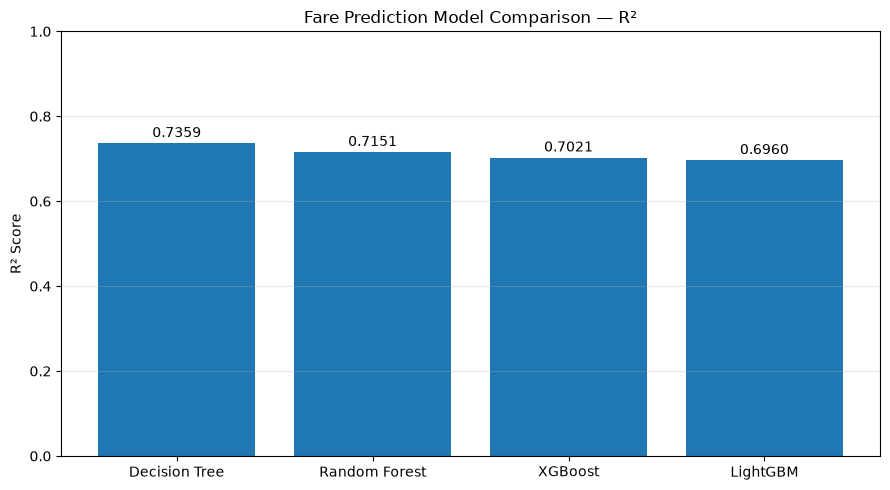

Saved: E:\SLIIT_Bacholer\Datathon2026\UrbanFlow-Datathon\results\figures\fare_model_r2_comparison.png


In [70]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create output directory
figure_dir = PROJECT_ROOT / "results" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["R2"]
)

plt.ylabel("R² Score")
plt.title("Fare Prediction Model Comparison — R²")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

# Show R² value above each bar
for bar, value in zip(bars, final_model_comparison["R2"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

output_path = figure_dir / "fare_model_r2_comparison.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

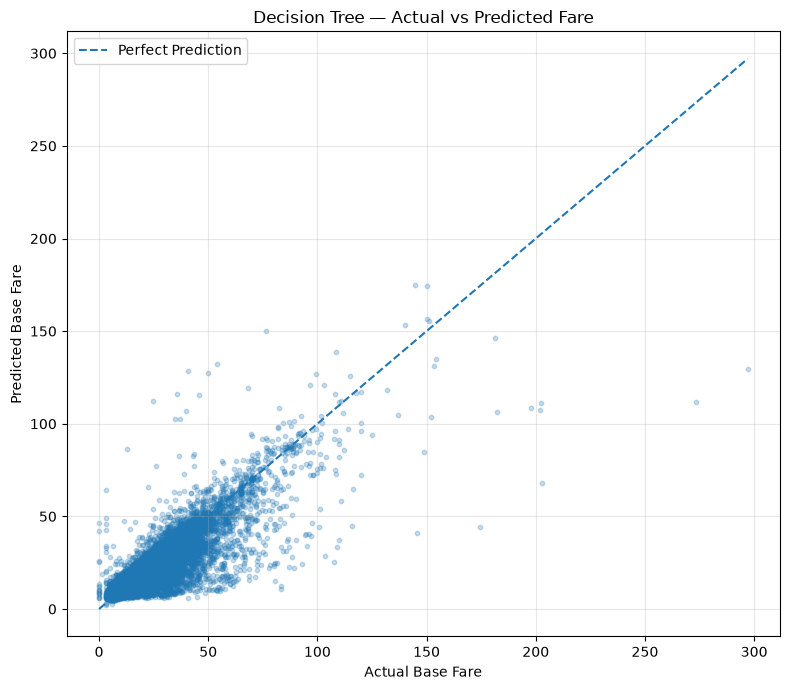

Saved: E:\SLIIT_Bacholer\Datathon2026\UrbanFlow-Datathon\results\figures\fare_actual_vs_predicted.png


In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Predict validation fares using the selected Decision Tree
y_validation_pred = decision_tree_run_4.predict(X_validation_np)

# Plot a reproducible sample so the chart stays readable
rng = np.random.default_rng(42)

sample_size = min(20_000, len(y_validation_np))

sample_idx = rng.choice(
    len(y_validation_np),
    size=sample_size,
    replace=False
)

actual_sample = y_validation_np[sample_idx]
predicted_sample = y_validation_pred[sample_idx]

plt.figure(figsize=(8, 7))

plt.scatter(
    actual_sample,
    predicted_sample,
    alpha=0.25,
    s=10
)

# Perfect-prediction reference line
plot_min = min(actual_sample.min(), predicted_sample.min())
plot_max = max(actual_sample.max(), predicted_sample.max())

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Base Fare")
plt.ylabel("Predicted Base Fare")
plt.title("Decision Tree — Actual vs Predicted Fare")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

output_path = figure_dir / "fare_actual_vs_predicted.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

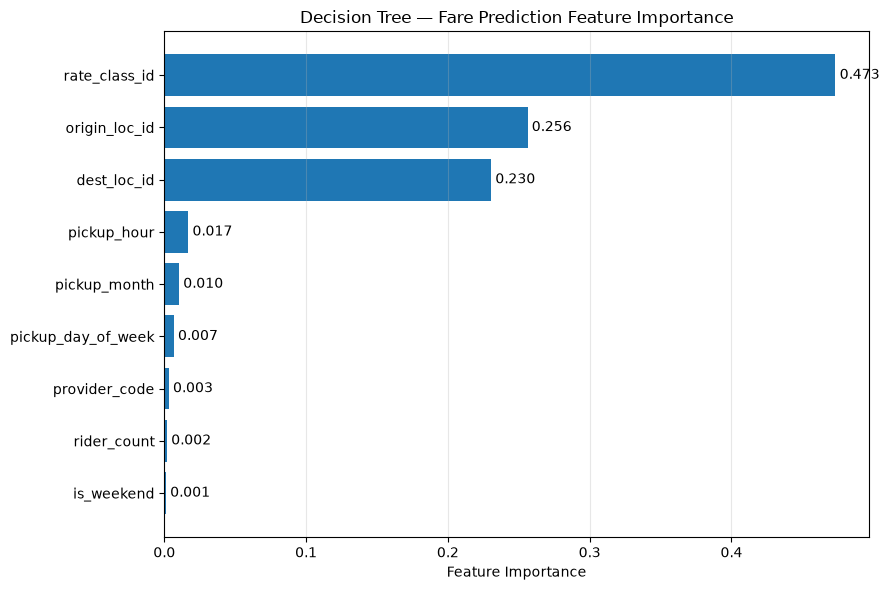

              Feature  Importance
2       rate_class_id    0.473332
3       origin_loc_id    0.256157
4         dest_loc_id    0.230458
5         pickup_hour    0.016869
7        pickup_month    0.010362
6  pickup_day_of_week    0.006661
0       provider_code    0.003137
1         rider_count    0.001880
8          is_weekend    0.001143
Saved: E:\SLIIT_Bacholer\Datathon2026\UrbanFlow-Datathon\results\figures\fare_feature_importance.png


In [72]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
    "provider_code",
    "rider_count",
    "rate_class_id",
    "origin_loc_id",
    "dest_loc_id",
    "pickup_hour",
    "pickup_day_of_week",
    "pickup_month",
    "is_weekend"
]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": decision_tree_run_4.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.title("Decision Tree — Fare Prediction Feature Importance")
plt.grid(axis="x", alpha=0.3)

for bar, value in zip(bars, feature_importance["Importance"]):
    plt.text(
        value + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()

output_path = figure_dir / "fare_feature_importance.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(feature_importance.sort_values("Importance", ascending=False))
print("Saved:", output_path)